### Toy model
This code guides the user through the process of creating a toy model and estimating path coefficients in anticipated directed acyclic graph (DAG).

In [ ]:
# #Imports
import numpy as np
import matplotlib
from matplotlib.cm import ScalarMappable
from matplotlib import pyplot as plt
%matplotlib inline     
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import sys
# ====================================================
# ======== LOAD TIGRAMITE ============================
# ====================================================
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.lpcmci import LPCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr

# ======== LOAD HELPER FUNCTIONS=======================
sys.path.append('/path/to/the/helper_functions/')
from helper_functions_causality import fix_graph, position_of_nodes, add_link, convert_dict_to_val_matrix, calculate_wright_coeffs

In [2]:
tau_max = 1
var_names = ['w*', 'N$_2$O', 'NO$_x$', 'O$_3$']

### Part I. Assumed causal connections

In [3]:
graph_a = np.empty((len (var_names), len(var_names), tau_max + 1), dtype='<U3')
graph_a[:] = ''

val_matrix_a = np.zeros_like(graph_a, dtype=float)

# From w* to N2O
graph_a[0, 1, 0] =  '-->'
graph_a[1, 0, 0] = '<--'
val_matrix_a[0, 1, 0] = 0.9 # Value is selected intuitively. Sign (positive/negative) is important.
val_matrix_a[1, 0, 0] = 0.9

# From N2O to NO2
graph_a[1, 2, 0] = '-->'
graph_a[2, 1, 0] = '<--'

val_matrix_a[1, 2, 0] = -0.9
val_matrix_a[2, 1, 0] = -0.9

#From NO2 to O3
graph_a[2, 3, 0] = '-->'
graph_a[3, 2, 0] = '<--'

val_matrix_a[2, 3, 0] = -0.9
val_matrix_a[3, 2, 0] = -0.9


special_nodes_a = {
    (0, 0): 'lightgrey',
    (1, 0): 'violet',
    (2, 0): 'violet',
    (3, 0): 'lightgrey',
}

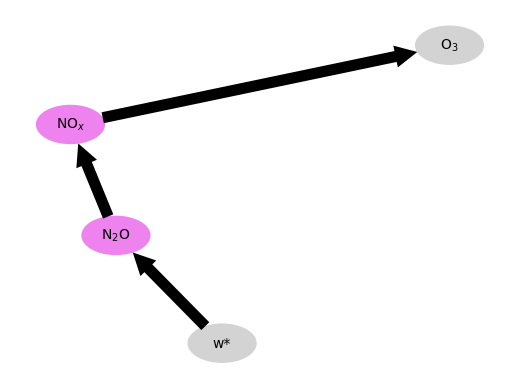

In [ ]:
#Lets have a brief look into our assumed causal graph

tp.plot_graph(
    graph=graph_a,
    var_names=var_names,
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    special_nodes= special_nodes_a
    )
plt.show()

### Part II. Toy model
##### Lets construct simple toy model to check whether causal discovery algorithm is able to detect anticipated connections

In [ ]:
seed = 7
lin_f = lambda x: x

links_coeffs = {0: [(((0, -1), 0.3, lin_f))], 

                1: [((1, -1), 0.3, lin_f),       # autocor.
                        ((0, -1), 0.4, lin_f)],  # w*--> N2O

                2: [((2, -1), 0.3, lin_f),       # autocor.
                    ((1, 0), -0.94, lin_f),      # N2O --> NO2
                    ],  

                3:[((3, -1), 0.3, lin_f),        # autocor.
                    ((2,0), -0.95, lin_f),       # NO2 --> O3
                        ]
                        }
# list of lengths of the timeseries (done for testing)
T_list = [120, 240]
df = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for T in T_list: 
    print (f"Analyzed {T} timesteps")
# Make some noise with different variance, alternatively just noises=None
# Specify dynamical noise term distributions, here unit variance Gaussians
    random_state = np.random.RandomState(seed)
    noises = noises = [random_state.randn for j in links_coeffs.keys()]
    

    data, nonstationarity_indicator  = toys.structural_causal_process(links_coeffs, T=T, noises=noises, seed=seed)
    data = scaler.fit_transform(data)
    T, N = data.shape

    dataframe = pp.DataFrame(data, 
                            datatime = {0:np.arange(len(data))}, 
                            var_names=var_names)


    df['toy']['No_mask'][T]['dataframe'] = dataframe
    Rparcorr = RobustParCorr(significance='analytic')
    lpcmci   = LPCMCI(dataframe=dataframe, cond_ind_test=Rparcorr, verbosity=0)

    # Run LPCMCI
    results = lpcmci.run_lpcmci(tau_max=tau_max,pc_alpha=0.02)
    dag = fix_graph(results['graph'])
    df['toy']['No_mask'][T]['dag'] = dag

Analyzed 120 timesteps
Analyzed 240 timesteps


In [6]:
# Revise the graph with 240 steps to form the DAG
dag_original_240 = df['toy']['No_mask'][240]['dag']
dag_revised_240 = add_link(dag_original_240.copy(), 1, 2, 0)

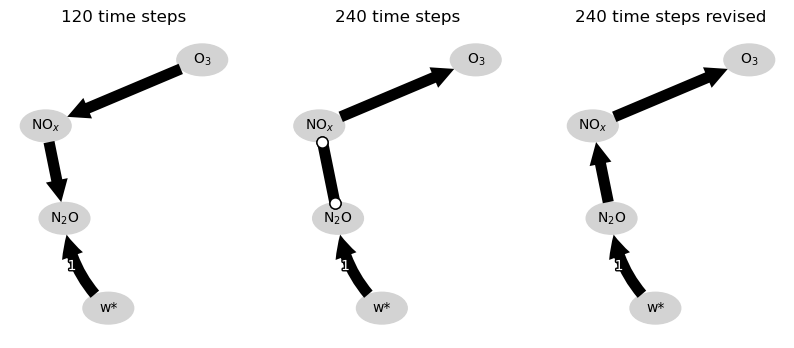

In [ ]:
#Lets check what the output from the toy model
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10,4))

axes[0].set_title("120 time steps")
tp.plot_graph(
    graph=df['toy']['No_mask'][120]['dag'],
    var_names=var_names,
    fig_ax=(fig, axes[0]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )

axes[1].set_title("240 time steps")
tp.plot_graph(
    graph=df['toy']['No_mask'][240]['dag'],
    var_names=var_names,
    fig_ax=(fig, axes[1]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )

axes[2].set_title("240 time steps revised")
tp.plot_graph(
    graph= dag_revised_240, # define the direction from N2O to NO2 with lag 0
    var_names=var_names,
    fig_ax=(fig, axes[2]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )    

plt.show()

In [ ]:
# Estimation of direct links

df_revised = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
df_revised ['toy']['No_mask']['dataframe'] = df['toy']['No_mask'][240]['dataframe']
all_results = calculate_wright_coeffs (df_revised, 'toy', graph_list = [dag_revised_240], var_names = var_names)
val_matrix_list  = convert_dict_to_val_matrix (var_names, all_results, 'beta')

0 No_mask
Processing key: No_mask
Skipping due to overlap: Cause w* and Effect w*
Skipping due to overlap: Cause N$_2$O and Effect N$_2$O
Skipping due to overlap: Cause NO$_x$ and Effect NO$_x$
Skipping due to overlap: Cause O$_3$ and Effect O$_3$


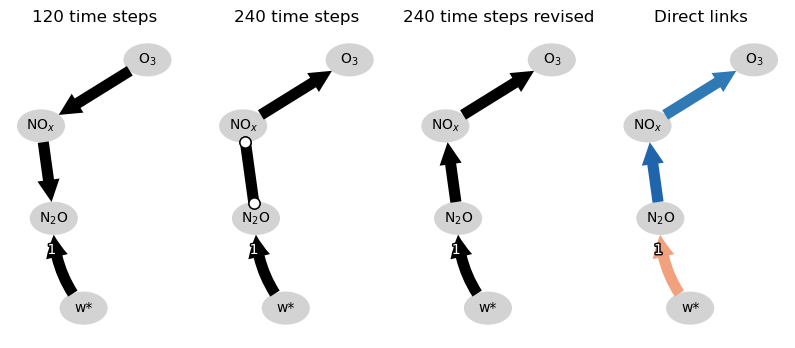

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10,4))

axes[0].set_title("120 time steps")
tp.plot_graph(
    graph=df['toy']['No_mask'][120]['dag'],
    var_names=var_names,
    fig_ax=(fig, axes[0]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )

axes[1].set_title("240 time steps")
tp.plot_graph(
    graph=df['toy']['No_mask'][240]['dag'],
    var_names=var_names,
    fig_ax=(fig, axes[1]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )

axes[2].set_title("240 time steps revised")
tp.plot_graph(
    graph=dag_revised_240,
    var_names=var_names,
    fig_ax=(fig, axes[2]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    )    

axes[3].set_title("Direct links")
tp.plot_graph(
    val_matrix = val_matrix_list[0], 
    graph=dag_revised_240,
    var_names=var_names,
    fig_ax=(fig, axes[3]),
    node_pos = position_of_nodes(var_names),
    node_size = 1.2,
    show_colorbar=False,
    cmap_nodes = None,
    )   
plt.show()

### Compile into one plot
### Figure 3

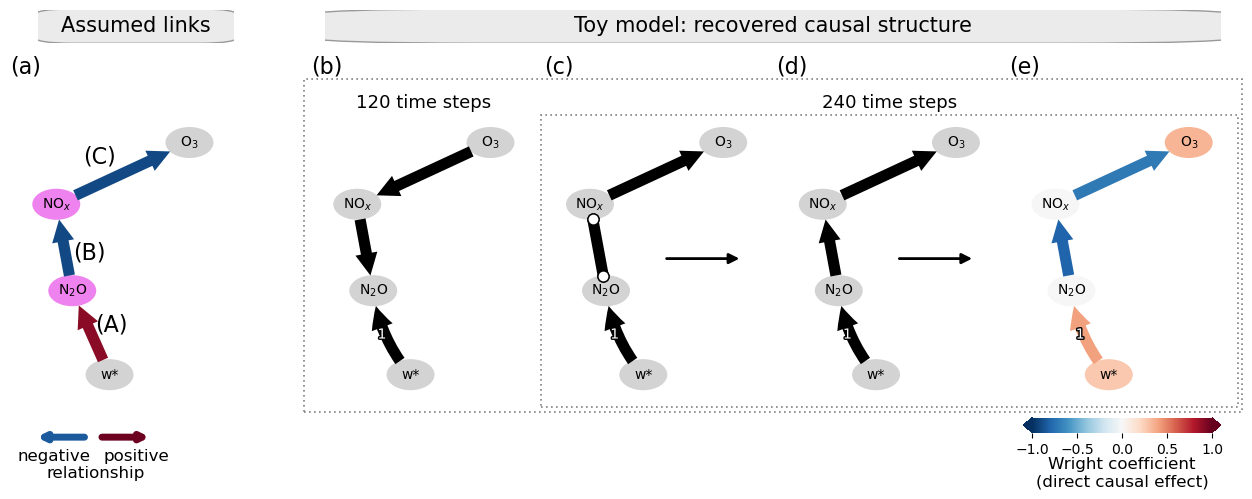

In [ ]:
fig = plt.figure(figsize=(14, 6))

# ============================================================
# 1. LAYOUT
# ============================================================

# Main panel positions
left_margin = 0.045
right_margin = 0.98
bottom = 0.13
top = 0.88

# Right block enclosing b-e
right_block = [0.26, 0.15, 0.69, 0.68]

# Axes geometry
x0, y0, w0, h0 = right_block
gap = 0.025
w_panel = (w0 - 5 * gap) / 4
y_panel = y0 + 0.10
h_panel = h0 - 0.20

# Explicit panel positions
panel_a_pos = [0.07, y_panel, w_panel, h_panel]
panel_b_pos = [x0 + gap,                 y_panel, w_panel, h_panel]
panel_c_pos = [x0 + 2 * gap + w_panel,   y_panel, w_panel, h_panel]
panel_d_pos = [x0 + 3 * gap + 2*w_panel, y_panel, w_panel, h_panel]
panel_e_pos = [x0 + 4 * gap + 3*w_panel, y_panel, w_panel, h_panel]

# Text / spacing settings
label_offset = 0.07
label_gap = 0.04

# ============================================================
# 2. HEADER BOXES
# ============================================================

ax_header_left = fig.add_axes([0.08, 0.85, 0.14, 0.055])
ax_header_right = fig.add_axes([
    panel_b_pos[0],                                           # left edge of panel b
    0.85,
    (panel_e_pos[0] + panel_e_pos[2]) - panel_b_pos[0],       # span from b to e
    0.055
])

for axh in [ax_header_left, ax_header_right]:
    axh.set_axis_off()

for axh, text in zip(
    [ax_header_left, ax_header_right],
    ['Assumed links', 'Toy model: recovered causal structure']
):
    patch = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.02,rounding_size=0.2",
        linewidth=1.0,
        edgecolor='0.6',
        facecolor='0.92'
    )
    axh.add_patch(patch)
    axh.text(0.5, 0.5, text, ha='center', va='center', fontsize=15)

# ============================================================
# 3. AXES
# ============================================================

ax_a = fig.add_axes(panel_a_pos)
ax_b = fig.add_axes(panel_b_pos)
ax_c = fig.add_axes(panel_c_pos)
ax_d = fig.add_axes(panel_d_pos)
ax_e = fig.add_axes(panel_e_pos)

axes_all = [ax_a, ax_b, ax_c, ax_d, ax_e]

# Axis positions for later use
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()
pos_d = ax_d.get_position()
pos_e = ax_e.get_position()

# ============================================================
# 4. PLOT PANELS
# ============================================================

# -------- Panel (a)
tp.plot_graph(
    graph=graph_a,
    val_matrix=val_matrix_a,
    var_names=var_names,
    fig_ax=(fig, ax_a),
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=False,
    cmap_edges='RdBu_r',
    vmin_edges=-1,
    vmax_edges=1,
    cmap_nodes=None,
    special_nodes=special_nodes_a,
    curved_radius=0,
    link_label_fontsize=0,
)

# -------- Panel (b)
tp.plot_graph(
    graph=df['toy']['No_mask'][120]['dag'],
    var_names=var_names,
    fig_ax=(fig, ax_b),
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=False,
    cmap_nodes=None,
    arrowhead_size=12,
    curved_radius=0.15
)

# -------- Panel (c)
tp.plot_graph(
    graph=df['toy']['No_mask'][240]['dag'],
    var_names=var_names,
    fig_ax=(fig, ax_c),
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=False,
    cmap_nodes=None,
    arrowhead_size=12,
    curved_radius=0.15
)

# -------- Panel (d)
tp.plot_graph(
    graph=dag_revised_240,
    var_names=var_names,
    fig_ax=(fig, ax_d),
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=False,
    cmap_nodes=None,
    arrowhead_size=12,
    curved_radius=0.15
)

# -------- Panel (e)
tp.plot_graph(
    val_matrix=val_matrix_list[0],
    graph=dag_revised_240,
    var_names=var_names,
    fig_ax=(fig, ax_e),
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=False,
    cmap_edges='RdBu_r',
    vmin_edges=-1,
    vmax_edges=1,
    cmap_nodes='RdBu_r',
    vmin_nodes=-1,
    vmax_nodes=1,
    arrowhead_size=12,
    curved_radius=0.15
)

# ============================================================
# 5. RECTANGLES
# ============================================================

# Big dotted rectangle around b-e
top_rect_be = pos_b.y1 + label_offset - 0.01
bottom_rect_be = pos_b.y0 - 0.015

rect_be = Rectangle(
    (pos_b.x0 - 0.015, bottom_rect_be),
    (pos_e.x1 - pos_b.x0) + 0.03,
    top_rect_be - bottom_rect_be,
    transform=fig.transFigure,
    fill=False,
    linewidth=1.2,
    linestyle=(0, (1, 2)),
    edgecolor='0.5'
)
fig.add_artist(rect_be)

# Small dotted rectangle around c-e
text_240_y = pos_c.y1 + 0.005
top_rect_ce = text_240_y - 0.006
bottom_rect_ce = pos_c.y0 - 0.007

rect_ce = Rectangle(
    (pos_c.x0 - 0.012, bottom_rect_ce),
    (pos_e.x1 - pos_c.x0) + 0.024,
    top_rect_ce - bottom_rect_ce,
    transform=fig.transFigure,
    fill=False,
    linewidth=1.2,
    linestyle=(0, (1, 2)),
    edgecolor='0.5'
)
fig.add_artist(rect_ce)

# ============================================================
# 6. PANEL LABELS AND TITLES
# ============================================================

fig.text(pos_a.x0 - 0.01, pos_a.y1 + label_offset, '(a)', fontsize=16)
fig.text(pos_b.x0 - 0.01, pos_b.y1 + label_offset, '(b)', fontsize=16)
fig.text(pos_c.x0 - 0.01, pos_c.y1 + label_offset, '(c)', fontsize=16)
fig.text(pos_d.x0 - 0.01, pos_d.y1 + label_offset, '(d)', fontsize=16)
fig.text(pos_e.x0 - 0.01, pos_e.y1 + label_offset, '(e)', fontsize=16)

# "120 time steps" above graph b
fig.text(
    pos_b.x0 + pos_b.width / 2,
    pos_b.y1 + 0.005,
    '120 time steps',
    ha='center',
    va='bottom',
    fontsize=13
)

# "240 time steps" centered above c-e
fig.text(
    (pos_c.x0 + pos_e.x1) / 2,
    pos_c.y1 + 0.005,
    '240 time steps',
    ha='center',
    va='bottom',
    fontsize=13
)

# ============================================================
# 7. TEXT INSIDE PANEL (a)
# ============================================================

ax_a.text(0.36, 0.25, '(A)', transform=ax_a.transAxes, fontsize=16)
ax_a.text(0.25, 0.50, '(B)', transform=ax_a.transAxes, fontsize=16)
ax_a.text(0.3, 0.83, '(C)', transform=ax_a.transAxes, fontsize=16)

# negative / positive relationship legend
arrow_y = -0.12
text_y_main = -0.20
text_y_sub = text_y_main - 0.06

ax_a.annotate(
    '',
    xy=(0.32, arrow_y), xytext=(0.05, arrow_y),
    xycoords='axes fraction', textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='<|-',
        lw=5,
        color=matplotlib.cm.RdBu_r(0.08)
    )
)

ax_a.annotate(
    '',
    xy=(0.65, arrow_y), xytext=(0.38, arrow_y),
    xycoords='axes fraction', textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        lw=5,
        color=matplotlib.cm.RdBu_r(0.99)
    )
)

ax_a.text(
    0.15, text_y_main, 'negative',
    transform=ax_a.transAxes, ha='center', fontsize=12, linespacing=0.9
)
ax_a.text(
    0.57, text_y_main, 'positive',
    transform=ax_a.transAxes, ha='center', fontsize=12, linespacing=0.9
)
ax_a.text(
    0.36, text_y_sub, 'relationship',
    transform=ax_a.transAxes, ha='center', fontsize=12, linespacing=0.9
)

# ============================================================
# 8. COLORBAR BELOW PANEL (e)
# ============================================================

cbar_height = 0.025
cbar_gap = 0.025

cax_edges = fig.add_axes([
    pos_e.x0,
    pos_e.y0 - cbar_gap - cbar_height,
    pos_e.width,
    cbar_height
])

norm = matplotlib.colors.Normalize(vmin=-1, vmax=1)
sm = ScalarMappable(norm=norm, cmap='RdBu_r')
sm.set_array([])

cb_edges = plt.colorbar(
    sm,
    cax=cax_edges,
    orientation='horizontal',
    extend='both'
)

cb_edges.outline.set_visible(False)
cb_edges.ax.tick_params(labelsize=10)

fig.text(
    pos_e.x0 + pos_e.width / 2,
    cax_edges.get_position().y0 - label_gap,
    'Wright coefficient\n(direct causal effect)',
    ha='center',
    va='top',
    fontsize=12
)

# ============================================================
# 9. ARROWS BETWEEN PANELS c -> d -> e
# ============================================================

y_mid = pos_c.y0 + pos_c.height / 2
half_len = 0.028

x_mid_cd = 0.5 * (pos_c.x1 + pos_d.x0) - 0.05
arrow_cd = FancyArrowPatch(
    (x_mid_cd - half_len, y_mid),
    (x_mid_cd + half_len, y_mid),
    transform=fig.transFigure,
    arrowstyle='-|>',
    linewidth=2,
    color='black',
    mutation_scale=15
)
fig.add_artist(arrow_cd)

x_mid_de = 0.5 * (pos_d.x1 + pos_e.x0) - 0.05
arrow_de = FancyArrowPatch(
    (x_mid_de - half_len, y_mid),
    (x_mid_de + half_len, y_mid),
    transform=fig.transFigure,
    arrowstyle='-|>',
    linewidth=2,
    color='black',
    mutation_scale=15
)
fig.add_artist(arrow_de)

# ============================================================
# 10. FINAL CLEANUP
# ============================================================

for ax in axes_all:
    ax.set_xticks([])
    ax.set_yticks([])


plt.show()
# plt.savefig ('toy_model.png', dpi = 300, bbox_inches = 'tight')